# Deconvolving the two configurations

`fire_cii_simulated_obs.ipynb` produced two simulated observations of the
same FIRE [CII] cube, identical except for which baselines CASA was allowed
to grid:

| configuration | `uvdist` | CASA PSF |
| --- | --- | --- |
| **extended** | all baselines | ~4.2 x 3.2 px |
| **compact** | 0~300 m | ~15.8 x 15.7 px |

Both are deconvolved here with the same solver and the same settings, so the
only thing that varies is the beam.

Everything is scored and displayed at **one common restoring beam, the
coarsest of the two**. Both of the obvious alternatives are wrong, in
opposite directions:

- *Each config restored with its own beam*: the compact one is graded
  against a truth blurred 3.7x more, which flatters it enough to invert the
  ranking (0.9748 vs the extended config's 0.9736).
- *Both restored with the finest beam*: the compact model is then shown at
  7x its own resolution, at scales its visibilities never constrained. The
  solver fills them with ringing and the compact deconvolution scores
  *worse* than its own dirty image (0.8454 vs 0.8547) -- a display
  artifact, not a real failure.

Convolving to the coarsest common resolution is the standard way to compare
arrays, and it is the only choice that gives a coherent answer.

Everything comes from `legacy/simple/`: `deconvolve.py` (FISTA with
reweighted L1 in a 2D-starlet x 1D-CDF-9/7 dictionary) and
`uv_to_image.ShiftInvariantOperator` for the forward model. Two settings
depart from that file's defaults, both established on this data earlier:

- **`REWEIGHT_MODE = "threshold"`** with the default 20-iteration burn-in:
  Candes reweighted L1, `T -> T / (|p|/T + eps)` against the previous
  model. This is what corrects the L1 shrinkage bias; without it the model
  keeps only ~75% of the flux. The cost on this noiseless cube is
  high-frequency ringing, because the reweighted threshold governs
  *detection* as well as shrinkage, so where the model is strong the gate
  collapses and structure the plain threshold would reject gets in.
  Measured on the extended config: flux 75% -> 107%, but sub-beam power
  2.3x -> 7.5x the truth's. (A `"bias-only"` mode is also available, which
  keeps the gate fixed and reweights only the shrinkage, following
  `Denoiser3D-IFU`; it debiases harder still -- flux 115%, sub-beam 8.2x.)
- **`K_SIGMA = 4`**, the tuned default. The dirty cubes now carry
  PSF-correlated noise at a 29:1 dynamic range (matched to the real NGC 7469
  data), so this threshold gates against a genuine noise floor rather than
  against PSF sidelobes. That matters more than any solver setting: on the
  earlier noiseless version the MAD estimate sat 2.6x too low and left
  ring-shaped starlet artifacts that the real NGC pipeline never produces.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit

sys.path.insert(0, "../legacy/simple")
import deconvolve as simple_deconv

DATA = "../simple_results/data"
CONFIGS = ["extended", "compact"]
CELL_ARCSEC = 0.04
DV_KMS = 20.0
CLEAN_SCALE = 0.5      # restore at half the dirty beam's FWHM

# (ny, nx, nchan) on disk -> (nchan, ny, nx), which is what the solver wants
true_cube = np.ascontiguousarray(np.moveaxis(np.load(f"{DATA}/fire_obs_true.npy"), 2, 0),
                                 dtype=np.float64)
dirty_cubes, psf_cubes = {}, {}
for name in CONFIGS:
    dirty_cubes[name] = np.ascontiguousarray(
        np.moveaxis(np.load(f"{DATA}/fire_obs_{name}_dirty.npy"), 2, 0), dtype=np.float64)
    psf_cubes[name] = np.ascontiguousarray(
        np.load(f"{DATA}/fire_obs_{name}_psf.npy"), dtype=np.float64)

n_ch, GRID, _ = true_cube.shape
print(f"truth {true_cube.shape}, {n_ch} channels @ {DV_KMS:g} km/s, {CELL_ARCSEC}\"/px")
for name in CONFIGS:
    print(f"  {name:9s}: dirty {dirty_cubes[name].shape}, psf {psf_cubes[name].shape}, "
          f"sum(PSF) = {psf_cubes[name][n_ch // 2].sum():.1f}")

truth (49, 204, 204), 49 channels @ 20 km/s, 0.04"/px
  extended : dirty (49, 204, 204), psf (49, 204, 204), sum(PSF) = 29.7
  compact  : dirty (49, 204, 204), psf (49, 204, 204), sum(PSF) = 84.7


In [2]:
models = {}
for name in CONFIGS:
    np.save(f"{DATA}/deconv_{name}_psf.npy", psf_cubes[name])
    np.save(f"{DATA}/deconv_{name}_dirty.npy", dirty_cubes[name])
    simple_deconv.PSF_PATH = f"{DATA}/deconv_{name}_psf.npy"
    simple_deconv.DIRTY_PATH = f"{DATA}/deconv_{name}_dirty.npy"
    simple_deconv.OUT_PATH = f"{DATA}/deconv_{name}_model.npy"
    simple_deconv.K_SIGMA = 4.0
    simple_deconv.REWEIGHT_MODE = "threshold"   # Candes reweighted L1
    simple_deconv.BURN_IN_ITERS = 20            # plain soft-threshold first
    print(f"\n================  {name}  ================")
    simple_deconv.main()
    models[name] = np.load(simple_deconv.OUT_PATH)


================  extended  ================
[setup] zero-spacing response |sum(PSF)| = 29.82 (MEASURED -> keep coarsest band)
[setup] using the FAST operator: PSF convolution via FFT (instant, exact for a single pointing, ~0.55% rms off at this mosaic's edge)
iter   0  residual_rms=6.8229e-07  flux=    0.00 Jy  active=689620  N(model)/dirty peak=0.000
iter   5  residual_rms=5.2963e-07  flux=    0.00 Jy  active=754804  N(model)/dirty peak=0.523
iter  10  residual_rms=5.2753e-07  flux=    0.00 Jy  active=753840  N(model)/dirty peak=0.542
iter  15  residual_rms=5.2737e-07  flux=    0.00 Jy  active=753701  N(model)/dirty peak=0.542
iter  20  residual_rms=5.2724e-07  flux=    0.01 Jy  active=651995  N(model)/dirty peak=0.545
iter  25  residual_rms=4.8519e-07  flux=    0.01 Jy  active=733216  N(model)/dirty peak=0.914
iter  30  residual_rms=4.8126e-07  flux=    0.01 Jy  active=723081  N(model)/dirty peak=0.884
iter  35  residual_rms=4.7911e-07  flux=    0.01 Jy  active=721031  N(model)/dir

In [3]:
# CLEAN beam: Gaussian fitted to each config's own main lobe, at CLEAN_SCALE
# of its FWHM, area-normalised. Truth and model are both convolved with it so
# they are compared at one resolution -- a sparse super-resolved model judged
# pixel-by-pixel against the smooth truth scores misleadingly badly.
def clean_beam_from(b, half=25, scale=1.0):
    cy, cx = np.unravel_index(np.argmax(b), b.shape)
    sub = b[cy - half:cy + half + 1, cx - half:cx + half + 1]
    yy, xx = np.mgrid[-half:half + 1, -half:half + 1]

    def gauss2d(coords, amp, x0, y0, sx, sy, th):
        x, y = coords
        a = np.cos(th) ** 2 / (2 * sx ** 2) + np.sin(th) ** 2 / (2 * sy ** 2)
        b_ = -np.sin(2 * th) / (4 * sx ** 2) + np.sin(2 * th) / (4 * sy ** 2)
        c = np.sin(th) ** 2 / (2 * sx ** 2) + np.cos(th) ** 2 / (2 * sy ** 2)
        return amp * np.exp(-(a * (x - x0) ** 2 + 2 * b_ * (x - x0) * (y - y0)
                              + c * (y - y0) ** 2))

    lobe = sub >= 0.2
    p, _ = curve_fit(gauss2d, (xx[lobe], yy[lobe]), sub[lobe],
                     p0=[1, 0, 0, 3, 2, 0], maxfev=40000)
    n = b.shape[0]
    gy, gx = np.mgrid[:n, :n] - n // 2
    g = gauss2d((gx, gy), 1.0, 0, 0, p[3] * scale, p[4] * scale, p[5])
    to_fwhm = 2 * np.sqrt(2 * np.log(2))
    fwhm = sorted([abs(p[3]) * to_fwhm, abs(p[4]) * to_fwhm])[::-1]
    return g / g.sum(), fwhm


# mode="same" offsets by one pixel on an even grid when the kernel peaks at
# N//2; undone here so smoothed and unsmoothed arrays stay aligned.
def smooth(img, kern):
    return np.roll(fftconvolve(img, kern, mode="same"), (-1, -1), axis=(0, 1))


# ONE common restoring beam for everything, taken from the COARSEST
# configuration. Two traps here, and it took hitting both to get this right:
#
#   * Restoring each config with its own beam grades them against different
#     references -- the compact config's own beam is 3.7x coarser, so its
#     truth is blurred 3.7x more, which flatters it enough to invert the
#     ranking (compact scored 0.9748 vs extended's 0.9736).
#   * Using the FINEST beam for both is just as wrong in the other
#     direction: it displays and scores the compact model at 7x its own
#     resolution, i.e. at scales its visibilities never constrained. The
#     solver fills them with rings, and the compact deconvolution then
#     scores *worse* than its own dirty image (0.8454 vs 0.8547) -- an
#     artifact of the display, not of the deconvolution.
#
# Convolving everything to the coarsest common resolution is the standard
# way to compare arrays, and it is the only one of the three that gives a
# coherent answer: both configs beat their dirty images, and the extended
# one wins.
coarsest = max(CONFIGS, key=lambda n: clean_beam_from(psf_cubes[n][n_ch // 2])[1][0])
common_kern, common_fwhm = clean_beam_from(psf_cubes[coarsest][n_ch // 2],
                                           scale=CLEAN_SCALE)
sm = lambda c: np.stack([smooth(pl, common_kern) for pl in c])
truth_s = sm(true_cube).sum(axis=0) * DV_KMS       # the same target for both

results = {}
for name in CONFIGS:
    _, fwhm = clean_beam_from(psf_cubes[name][n_ch // 2], scale=CLEAN_SCALE)
    beam_sum = psf_cubes[name][n_ch // 2].sum()

    model_s = sm(models[name]).sum(axis=0) * DV_KMS
    dirty_s = smooth(dirty_cubes[name].sum(axis=0) * DV_KMS / beam_sum, common_kern)

    model_raw = models[name].sum(axis=0) * DV_KMS       # NO restoring beam
    raw_truth_m0 = true_cube.sum(axis=0) * DV_KMS

    results[name] = dict(
        fwhm=fwhm, truth=truth_s, model=model_s, dirty=dirty_s,
        model_raw=model_raw,
        peak_raw_pct=100 * model_raw.max() / raw_truth_m0.max(),
        corr_raw=np.corrcoef(model_raw.ravel(), raw_truth_m0.ravel())[0, 1],
        flux=100 * models[name].sum() / true_cube.sum(),
        nonzero=100 * (models[name] > 0).mean(),
        peak_pct=100 * model_s.max() / truth_s.max(),
        corr_model=np.corrcoef(model_s.ravel(), truth_s.ravel())[0, 1],
        corr_dirty=np.corrcoef(dirty_s.ravel(), truth_s.ravel())[0, 1],
        rmse_model=np.sqrt(((model_s - truth_s) ** 2).mean()) / truth_s.std(),
        rmse_dirty=np.sqrt(((dirty_s - truth_s) ** 2).mean()) / truth_s.std(),
    )

print(f"all scores use one common restoring beam: "
      f"{common_fwhm[0] * CLEAN_SCALE:.2f} x {common_fwhm[1] * CLEAN_SCALE:.2f} px "
      f"(= {CLEAN_SCALE:g} x the {coarsest} dirty beam, the coarsest of the two)\n")
print("scores at the common beam, plus the RAW (unrestored) model vs the raw truth:\n")
print(f"{'config':10s} {'dirty beam':>12s} {'flux%':>7s} {'peak%':>7s} {'nonzero%':>9s} "
      f"{'corr model':>11s} {'corr dirty':>11s} {'RMSE model':>11s} "
      f"{'raw peak%':>10s} {'raw corr':>9s}")
for name in CONFIGS:
    r = results[name]
    print(f"{name:10s} {r['fwhm'][0]:5.2f}x{r['fwhm'][1]:<6.2f} {r['flux']:7.1f} "
          f"{r['peak_pct']:7.1f} {r['nonzero']:9.1f} {r['corr_model']:11.4f} {r['corr_dirty']:11.4f} "
          f"{r['rmse_model']:11.3f} {r['peak_raw_pct']:10.1f} {r['corr_raw']:9.4f}")

all scores use one common restoring beam: 5.72 x 5.51 px (= 0.5 x the compact dirty beam, the coarsest of the two)

scores at the common beam, plus the RAW (unrestored) model vs the raw truth:

config       dirty beam   flux%   peak%  nonzero%  corr model  corr dirty  RMSE model  raw peak%  raw corr
extended    5.84x4.98      96.3   104.5      35.0      0.9423      0.9272       0.394      185.4    0.7313
compact    11.45x11.02     95.8   122.4      31.0      0.9354      0.9143       0.425      215.5    0.5699


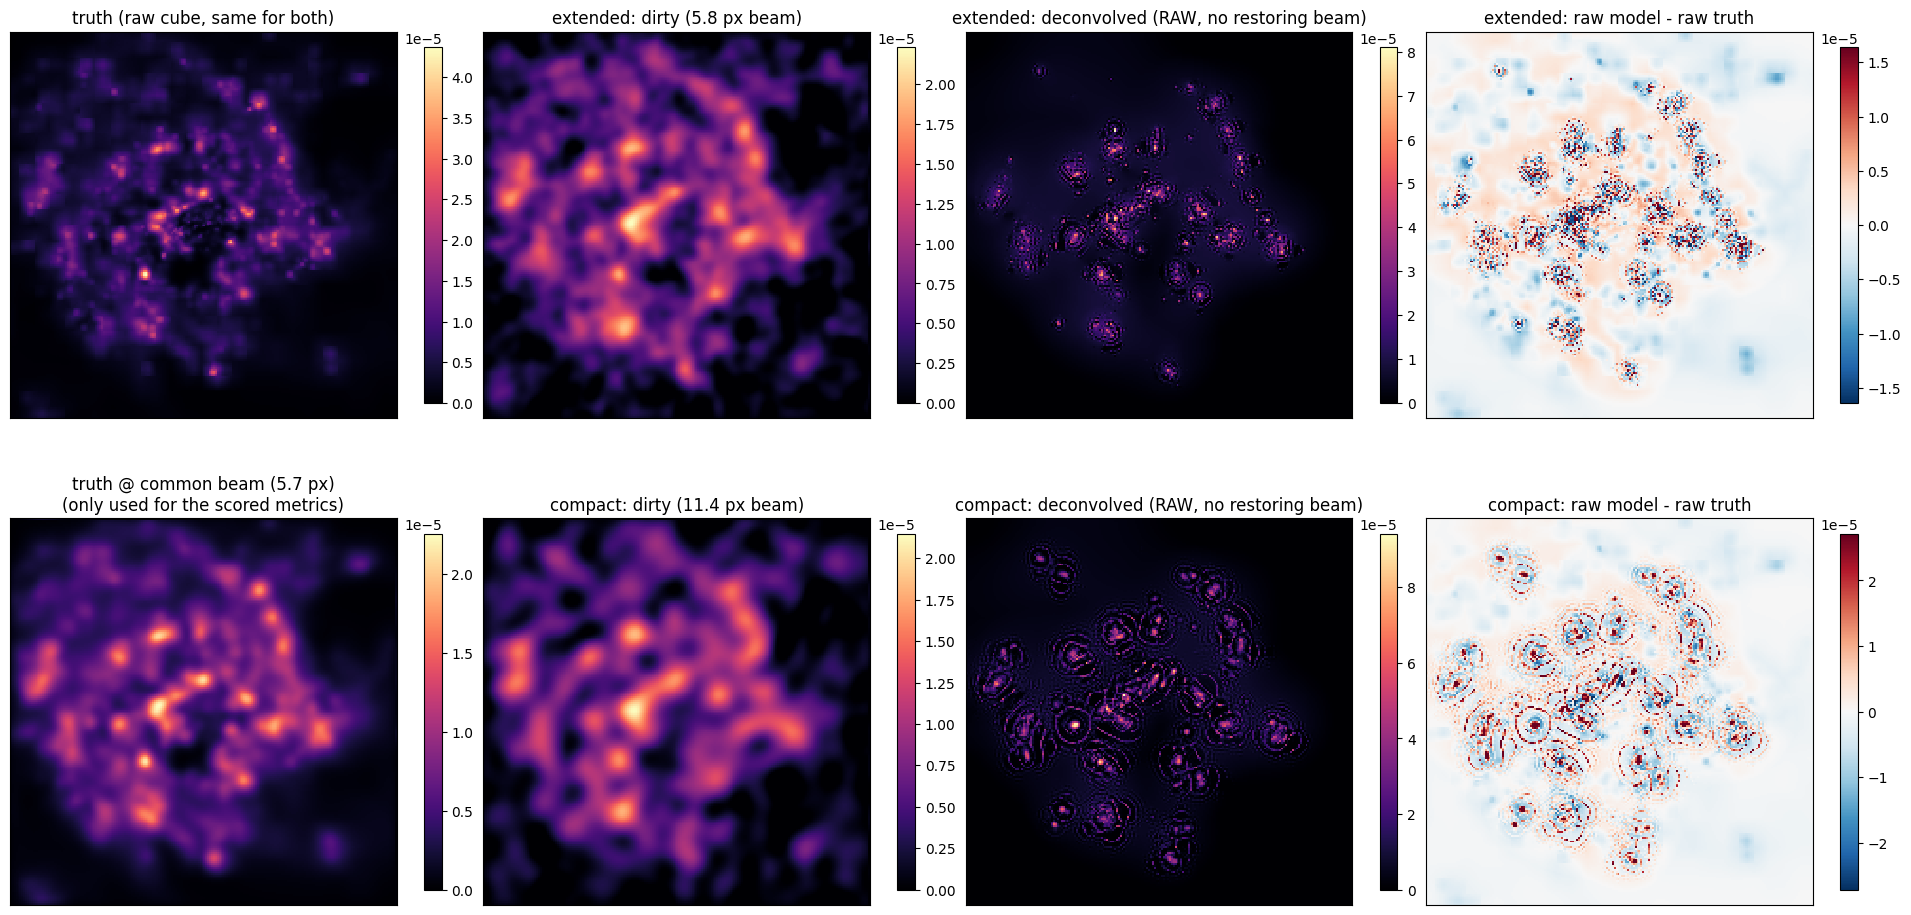

In [4]:
# No crop needed: the PSFs were gridded directly onto the FIRE crop's own
# 204px field (scripts/grid_fire_configs_with_casa.py), so there is no
# embedding and no dead space to cut away.
n_src = GRID
s = slice(None)
pix_kpc = (20000 / 1024) / 1000.0
ext = np.array([-1, 1, -1, 1]) * n_src / 2 * pix_kpc

fig, axes = plt.subplots(2, 4, figsize=(19, 9.6), constrained_layout=True)

# The truth is one cube, the same for both rows -- it is the raw FIRE model,
# not anything config-specific -- so it is drawn once, unsmoothed. The model
# and dirty panels below are at the common (coarsest) restoring beam, and the
# residual panels difference against the truth smoothed to that same beam.
raw_truth = true_cube.sum(axis=0) * DV_KMS
im = axes[0, 0].imshow(raw_truth[s, s], origin="lower", extent=ext, cmap="magma",
                       vmin=0, vmax=raw_truth[s, s].max(), interpolation="nearest")
axes[0, 0].set_title("truth (raw cube, same for both)", fontsize=12)
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.02)

# ...and again at the common restoring beam. The MODEL panels are now shown
# raw, with no restoring beam at all, so that the sub-beam structure the
# deconvolution recovered is actually visible -- restoring at 8 px would
# smooth away the very thing worth looking at. Compare those against the raw
# truth at top-left; this smoothed panel is only the reference the scored
# metrics use.
im_t = axes[1, 0].imshow(truth_s[s, s], origin="lower", extent=ext, cmap="magma",
                         vmin=0, vmax=truth_s[s, s].max(), interpolation="nearest")
axes[1, 0].set_title(f"truth @ common beam ({common_fwhm[0] * CLEAN_SCALE:.1f} px)"
                     "\n(only used for the scored metrics)", fontsize=12)
fig.colorbar(im_t, ax=axes[1, 0], fraction=0.046, pad=0.02)

# Every panel gets its own scale and its own colorbar: these are different
# quantities at different amplitudes, and a shared vmax just crushes some.
for row, name in enumerate(CONFIGS):
    r = results[name]
    panels = [
        (r["dirty"][s, s], f"{name}: dirty ({r['fwhm'][0]:.1f} px beam)", False),
        (r["model_raw"][s, s], f"{name}: deconvolved (RAW, no restoring beam)", False),
        (r["model_raw"][s, s] - raw_truth[s, s], f"{name}: raw model - raw truth", True),
    ]
    for col, (img, title, diverging) in enumerate(panels, start=1):
        ax = axes[row, col]
        if diverging:
            lim = np.percentile(np.abs(img), 99)
            kw = dict(cmap="RdBu_r", vmin=-lim, vmax=lim)
        else:
            kw = dict(cmap="magma", vmin=0, vmax=img.max())
        im = ax.imshow(img, origin="lower", extent=ext, interpolation="nearest", **kw)
        ax.set_title(title, fontsize=12)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)

plt.show()

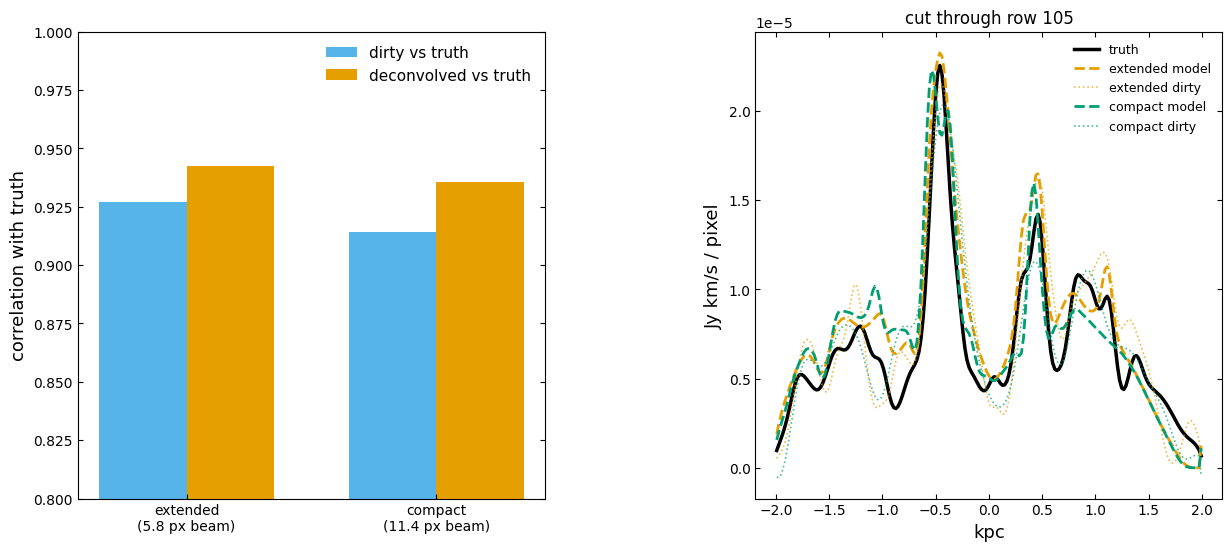

In [5]:
fig, (ax_bar, ax_cut) = plt.subplots(1, 2, figsize=(13.5, 5.4), constrained_layout=True)

# How much of the gap between the dirty image and the truth each config closes.
x = np.arange(len(CONFIGS))
w = 0.35
ax_bar.bar(x - w / 2, [results[n]["corr_dirty"] for n in CONFIGS], w,
           color="#56B4E9", label="dirty vs truth")
ax_bar.bar(x + w / 2, [results[n]["corr_model"] for n in CONFIGS], w,
           color="#E69F00", label="deconvolved vs truth")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([f"{n}\n({results[n]['fwhm'][0]:.1f} px beam)" for n in CONFIGS])
ax_bar.set_ylabel("correlation with truth", fontsize=13)
ax_bar.set_ylim(0.8, 1.0)
ax_bar.legend(frameon=False, fontsize=11)
ax_bar.tick_params(direction="in", right=True)
ax_bar.set_box_aspect(1)

# A cut through the brightest row, both configs, at their own resolutions.
row = int(np.unravel_index(np.argmax(truth_s), truth_s.shape)[0])
xs = np.linspace(ext[0], ext[1], n_src)
ax_cut.plot(xs, truth_s[row, s], color="black", lw=2.5, label="truth")
for name, colour in [("extended", "#E69F00"), ("compact", "#009E73")]:
    ax_cut.plot(xs, results[name]["model"][row, s], color=colour, lw=2, ls="--",
                label=f"{name} model")
    ax_cut.plot(xs, results[name]["dirty"][row, s], color=colour, lw=1.2, ls=":",
                alpha=0.7, label=f"{name} dirty")
ax_cut.set_xlabel("kpc", fontsize=13)
ax_cut.set_ylabel("Jy km/s / pixel", fontsize=13)
ax_cut.set_title(f"cut through row {row}", fontsize=12)
ax_cut.legend(frameon=False, fontsize=9)
ax_cut.tick_params(direction="in", top=True, right=True)
ax_cut.set_box_aspect(1)

plt.show()

## The same thing with reweighting off

Where the ring-shaped artifacts in the raw models come from, in order of how
much they contribute:

1. **The reweighting removes the regularisation.** `T -> T/(|p|/T + eps)`
   means that wherever the model is already strong the threshold collapses
   toward zero, so those coefficients are effectively unpenalised. The
   solver then fits the data almost freely, and on a noiseless,
   ill-conditioned problem (`min|OTF|` ~ 2e-6, no hard nulls) the
   poorly-constrained modes absorb whatever reduces the residual.
2. **Super-resolution beyond the data.** The compact beam is 16 px, so
   recovering 1-2 px structure means extrapolating ~8x past anything the
   visibilities measured. There is no information there to get right.
3. **The dictionary's atom shape sets the artifact's *shape*.** The spatial
   transform is an a-trous starlet built on a B3 spline
   (`legacy/simple/wavelets.py`), whose atoms are isotropic concentric
   rings. A compact source represented by a few coarse-scale starlet
   coefficients reconstructs *as* a sum of rings -- which is why the
   artifacts are ring-shaped rather than random speckle.
4. **No noise.** `K_SIGMA` gates against a MAD estimate that, with no noise
   present, measures signal structure, so it under-suppresses.

(1) is the only one that is a free choice, so this cell re-runs both
configurations with reweighting off and shows the raw models side by side.
Expect much cleaner structure and a much larger flux deficit -- that is the
L1 shrinkage bias reweighting exists to remove.

In [7]:
models_norw = {}
for name in CONFIGS:
    simple_deconv.PSF_PATH = f"{DATA}/deconv_{name}_psf.npy"
    simple_deconv.DIRTY_PATH = f"{DATA}/deconv_{name}_dirty.npy"
    simple_deconv.OUT_PATH = f"{DATA}/deconv_{name}_model_norw.npy"
    simple_deconv.K_SIGMA = 4.0
    simple_deconv.BURN_IN_ITERS = simple_deconv.N_ITER    # reweighting never engages
    print(f"\n================  {name} (no reweighting)  ================")
    simple_deconv.main()
    models_norw[name] = np.load(simple_deconv.OUT_PATH)

raw_truth_m0 = true_cube.sum(axis=0) * DV_KMS
highpass = lambda img: img - smooth(img, common_kern)
hf_truth = highpass(raw_truth_m0).std()

print(f"\n{'config':10s} {'reweighting':>13s} {'flux%':>7s} {'raw peak%':>10s} "
      f"{'raw corr':>9s} {'ring power':>11s}")
for name in CONFIGS:
    for label, m in [("on", models[name]), ("off", models_norw[name])]:
        raw = m.sum(axis=0) * DV_KMS
        print(f"{name:10s} {label:>13s} {100 * m.sum() / true_cube.sum():7.1f} "
              f"{100 * raw.max() / raw_truth_m0.max():10.1f} "
              f"{np.corrcoef(raw.ravel(), raw_truth_m0.ravel())[0, 1]:9.4f} "
              f"{highpass(raw).std() / hf_truth:11.2f}")
print("\n'ring power' = sub-beam structure relative to the truth's; 1.0 would "
      "mean the model is exactly as sharp as the truth.")


================  extended (no reweighting)  ================
[setup] zero-spacing response |sum(PSF)| = 29.82 (MEASURED -> keep coarsest band)
[setup] using the FAST operator: PSF convolution via FFT (instant, exact for a single pointing, ~0.55% rms off at this mosaic's edge)
iter   0  residual_rms=6.8229e-07  flux=    0.00 Jy  active=689620  N(model)/dirty peak=0.000
iter   5  residual_rms=5.2963e-07  flux=    0.00 Jy  active=754804  N(model)/dirty peak=0.523
iter  10  residual_rms=5.2753e-07  flux=    0.00 Jy  active=753840  N(model)/dirty peak=0.542
iter  15  residual_rms=5.2737e-07  flux=    0.00 Jy  active=753701  N(model)/dirty peak=0.542
iter  20  residual_rms=5.2724e-07  flux=    0.00 Jy  active=753773  N(model)/dirty peak=0.545
iter  25  residual_rms=5.2716e-07  flux=    0.00 Jy  active=753776  N(model)/dirty peak=0.545
iter  30  residual_rms=5.2715e-07  flux=    0.00 Jy  active=753785  N(model)/dirty peak=0.545
iter  35  residual_rms=5.2710e-07  flux=    0.00 Jy  active=753

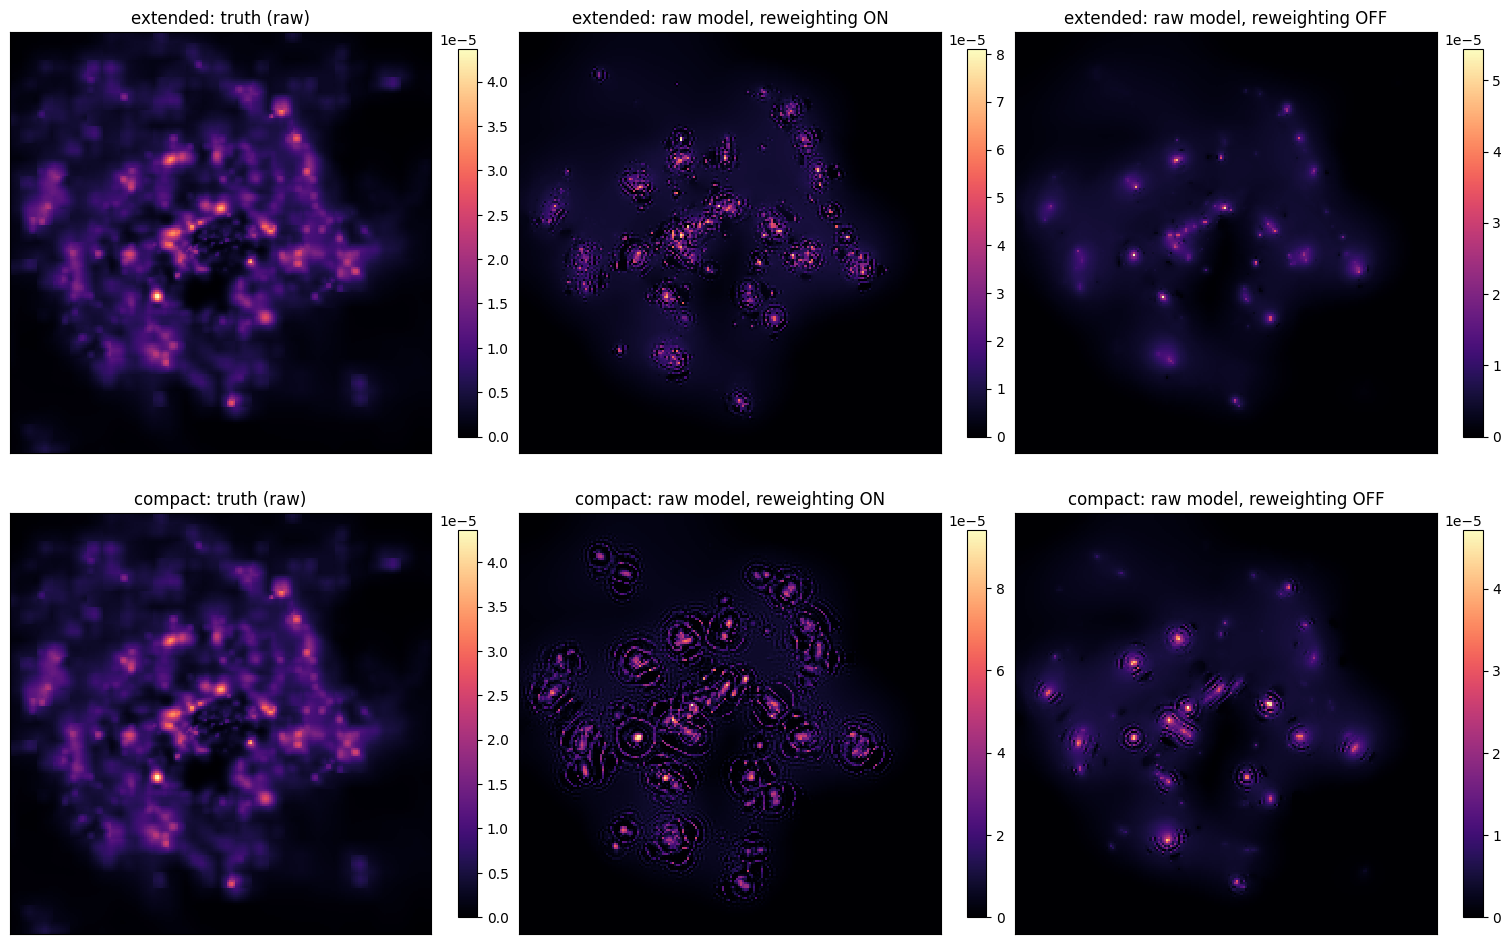

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9.6), constrained_layout=True)

for row, name in enumerate(CONFIGS):
    raw_rw = models[name].sum(axis=0) * DV_KMS
    raw_no = models_norw[name].sum(axis=0) * DV_KMS
    panels = [
        (raw_truth_m0[s, s], f"{name}: truth (raw)"),
        (raw_rw[s, s], f"{name}: raw model, reweighting ON"),
        (raw_no[s, s], f"{name}: raw model, reweighting OFF"),
    ]
    for col, (img, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(img, origin="lower", extent=ext, cmap="magma",
                       vmin=0, vmax=img.max(), interpolation="nearest")
        ax.set_title(title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(1)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.show()